# Tiền xử lý dữ liệu và trích xuất đặc trưng cho Depth Forest (depth_robust_v2)

Notebook này thực hiện trích xuất landmark khuôn mặt bằng MediaPipe, tính toán đặc trưng hình học kết hợp chiều sâu (`depth_robust_v2`), và làm giàu đặc trưng qua thời gian.


In [1]:
from pathlib import Path
import sys
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Cấu hình đường dẫn
ROOT = Path('/home/bear/Documents/Workspace/Thesis20252/engagement-cpu')
sys.path.insert(0, str(ROOT / 'src'))

from engagement_daisee.rnn.extract_features import (
    _create_face_landmarker,
    _build_frame_feature,
    _window_frames,
    _interpolate_missing_v2,
    ENHANCED_LANDMARKS,
    LEFT_EYE,
    RIGHT_EYE
)

# File video mẫu
VIDEO_PATH = Path('/home/bear/Documents/Workspace/Thesis20252/Engagement_DAiSEE/data/raw/daisee/DAiSEE/DataSet/Test/500044/5000441001/5000441001.avi')

OUT_DIR = ROOT / 'notebooks' / 'preprocess'
OUT_DIR.mkdir(parents=True, exist_ok=True)
LATEX_DIR = Path('/home/bear/Documents/Workspace/Thesis20252/Thesis/SOICT_DATN_Base/Hinhve/engagement_cpu/preprocess')
LATEX_DIR.mkdir(parents=True, exist_ok=True)

# Trích xuất khung hình giữa của video để minh họa
cap = cv2.VideoCapture(str(VIDEO_PATH))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
middle_index = frame_count // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, middle_index)
ok, frame_bgr = cap.read()
cap.release()

if not ok:
    raise RuntimeError('Không đọc được video')
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

detector = _create_face_landmarker()
result = detector.process(frame_rgb)
if not result.multi_face_landmarks:
    raise RuntimeError('Không phát hiện khuôn mặt')
face = result.multi_face_landmarks[0]
points = np.asarray([[lm.x * width, lm.y * height, lm.z] for lm in face.landmark])
print(f'Video: {VIDEO_PATH.name}, Kích thước: {width}x{height}, Số frame: {frame_count}, FPS: {fps}')


Video: 5000441001.avi, Kích thước: 640x480, Số frame: 300, FPS: 30.0


W0000 00:00:1782472033.325626  147392 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782472033.388307  147392 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782472033.394936  147406 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782472033.402542  147401 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782472033.438389  147399 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 1. Phát hiện Landmark và tập điểm đặc trưng
Biểu đồ dưới đây minh họa các bước từ khung hình gốc, phát hiện 478 landmark khuôn mặt và lọc ra 25 landmark thuộc tập điểm tối ưu của `depth_robust_v2`.


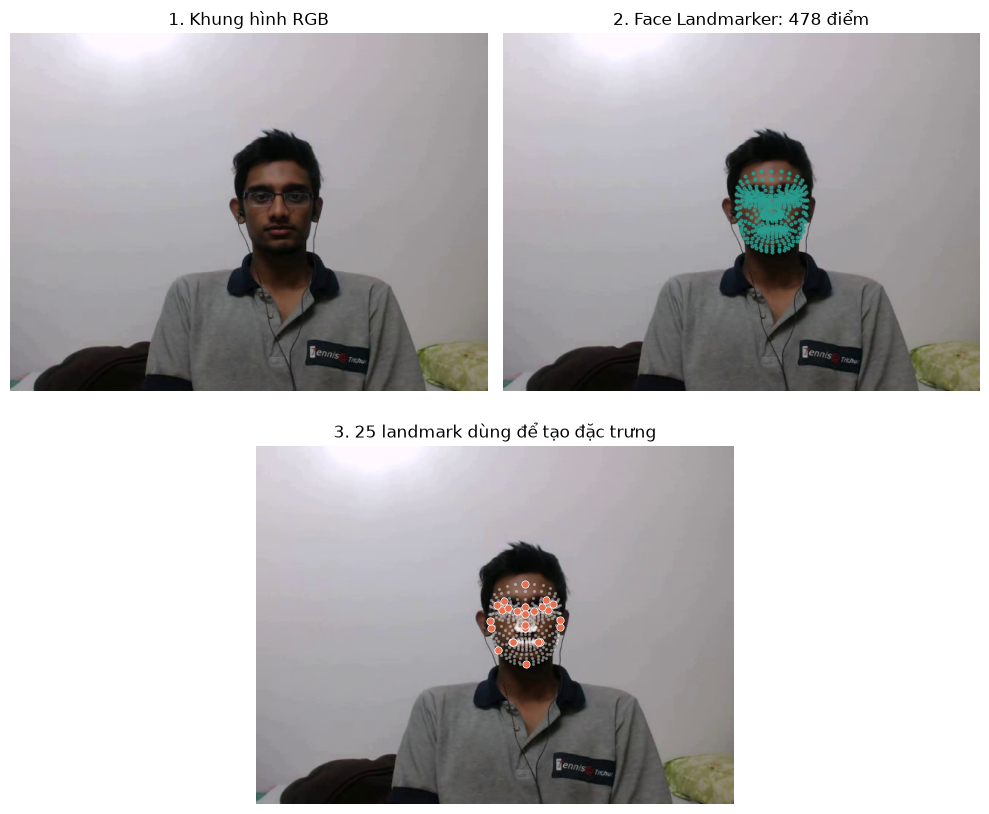

In [2]:
selected_ids = sorted(set(ENHANCED_LANDMARKS))
fig = plt.figure(figsize=(10, 8.5))
gs = gridspec.GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2:])
ax3 = fig.add_subplot(gs[1, 1:3])

for ax in [ax1, ax2, ax3]:
    ax.imshow(frame_rgb)
    ax.axis('off')

ax1.set_title('1. Khung hình RGB')
ax2.scatter(points[:, 0], points[:, 1], s=4, c='#2A9D8F', alpha=0.75)
ax2.set_title(f'2. Face Landmarker: {len(points)} điểm')
ax3.scatter(points[:, 0], points[:, 1], s=2, c='white', alpha=0.30)
ax3.scatter(points[selected_ids, 0], points[selected_ids, 1], s=28, c='#E76F51', edgecolor='white', linewidth=0.5)
ax3.set_title(f'3. {len(selected_ids)} landmark dùng để tạo đặc trưng')

fig.tight_layout()
fig.savefig(OUT_DIR / '01_cac_buoc_phat_hien_landmark.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '01_cac_buoc_phat_hien_landmark.png', bbox_inches='tight', facecolor='white')
plt.show()


## 2. Các nhóm Landmark tạo đặc trưng chính
Gồm: Mắt trái (EAR), Mắt phải (EAR), Miệng (MAR) và Hình học đầu (các điểm chính xác định hướng xoay khuôn mặt).


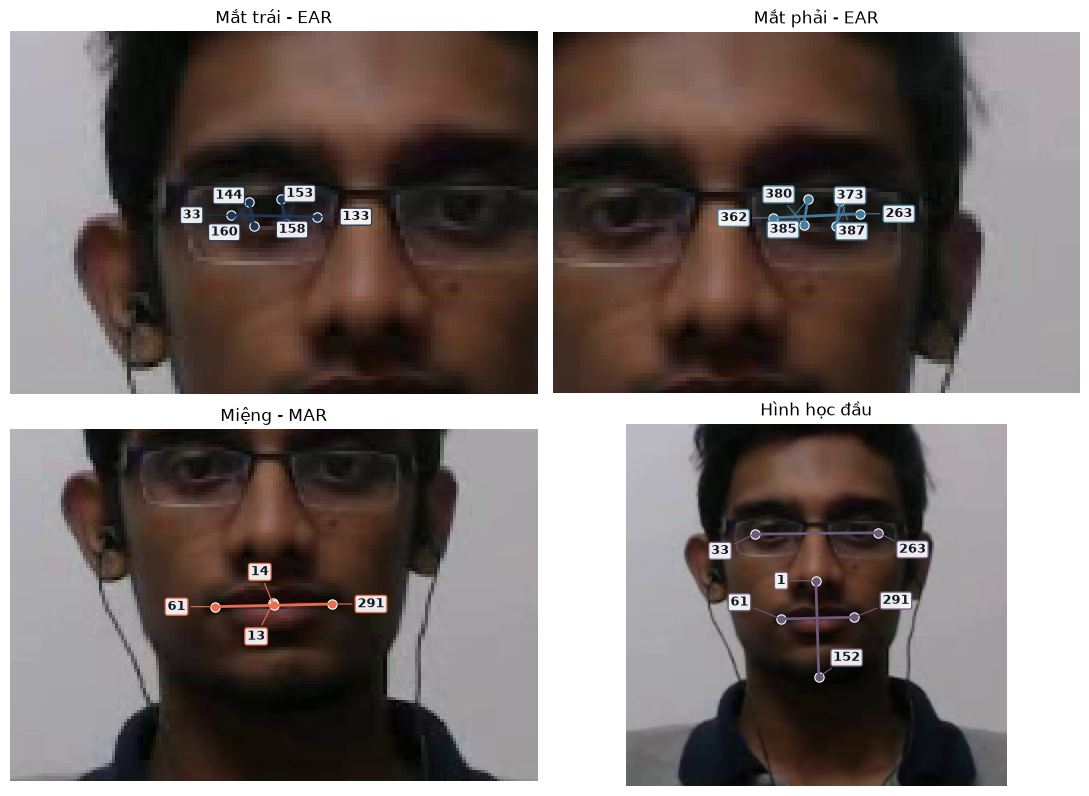

In [3]:
groups = [
    ('Mắt trái - EAR', LEFT_EYE, '#1D3557'),
    ('Mắt phải - EAR', RIGHT_EYE, '#457B9D'),
    ('Miệng - MAR', [61, 13, 291, 14], '#E76F51'),
    ('Hình học đầu', [33, 263, 1, 152, 61, 291], '#6D597A'),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
label_offsets = {
    'Mắt trái - EAR': [(-28, 0), (-18, -22), (8, -22), (28, 0), (10, 22), (-18, 22)],
    'Mắt phải - EAR': [(-28, 0), (-18, -22), (8, -22), (28, 0), (10, 22), (-18, 22)],
    'Miệng - MAR': [(-28, 0), (-12, -24), (28, 0), (-10, 24)],
    'Hình học đầu': [(-25, -12), (25, -12), (-25, 0), (20, 14), (-30, 12), (30, 12)],
}

for ax, (title, ids, color) in zip(axes.flat, groups):
    ax.imshow(frame_rgb)
    ax.scatter(points[ids, 0], points[ids, 1], s=45, c=color, edgecolor='white', linewidth=0.8)
    for idx, offset in zip(ids, label_offsets[title]):
        ax.annotate(str(idx), points[idx, :2], xytext=offset, textcoords='offset points',
                    color='#111827', fontsize=9, weight='bold', ha='center', va='center',
                    bbox={'boxstyle': 'round,pad=0.18', 'fc': 'white', 'ec': color, 'alpha': 0.92},
                    arrowprops={'arrowstyle': '-', 'color': color, 'lw': 0.8})
    if 'Mắt' in title:
        for a, b in [(0, 3), (1, 5), (2, 4)]:
            ax.plot(points[[ids[a], ids[b]], 0], points[[ids[a], ids[b]], 1], color=color, lw=2)
    elif 'Miệng' in title:
        ax.plot(points[[61, 291], 0], points[[61, 291], 1], color=color, lw=2)
        ax.plot(points[[13, 14], 0], points[[13, 14], 1], color=color, lw=2)
    else:
        ax.plot(points[[33, 263], 0], points[[33, 263], 1], color=color, lw=2)
        ax.plot(points[[1, 152], 0], points[[1, 152], 1], color=color, lw=2)
        ax.plot(points[[61, 291], 0], points[[61, 291], 1], color=color, lw=2)
    
    margin_x = 50 if 'Mắt' in title else 65
    margin_y = 38 if 'Mắt' in title else 55
    ax.set_xlim(points[ids, 0].min() - margin_x, points[ids, 0].max() + margin_x)
    ax.set_ylim(points[ids, 1].max() + margin_y, points[ids, 1].min() - margin_y)
    ax.set_title(title)
    ax.axis('off')

fig.tight_layout()
fig.savefig(OUT_DIR / '02_nhom_landmark_tao_dac_trung.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '02_nhom_landmark_tao_dac_trung.png', bbox_inches='tight', facecolor='white')
plt.show()


## 3. Vector đặc trưng 168 chiều của một frame (depth_robust_v2)
Biểu đồ cột biểu diễn các thành phần đặc trưng được trích xuất từ 1 frame.


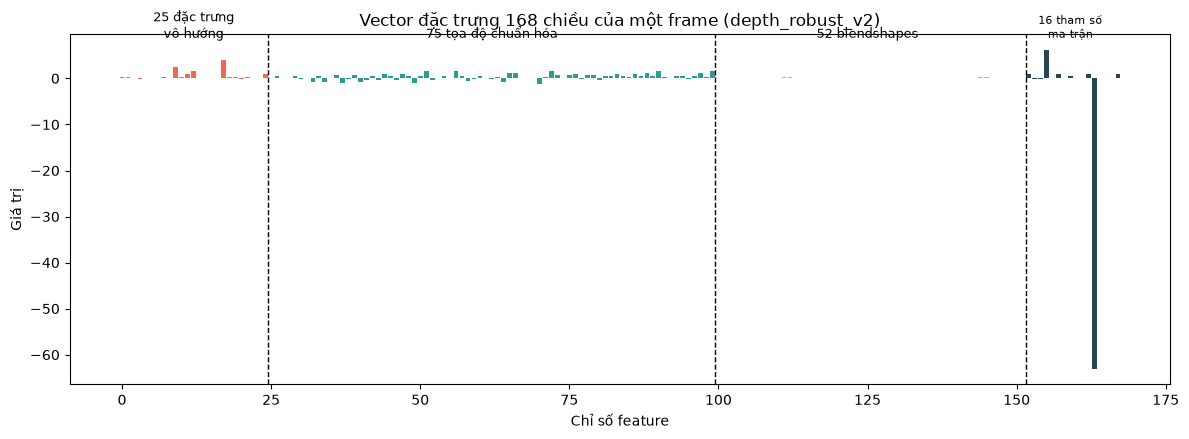

In [4]:
feature_168 = _build_frame_feature(
    face,
    feature_set='depth_robust_v2',
    image_aspect_ratio=width/height,
    face_blendshapes=getattr(result, 'face_blendshapes', None),
    facial_transformation_matrixes=getattr(result, 'facial_transformation_matrixes', None)
)

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = ['#E76F51'] * 25 + ['#2A9D8F'] * 75 + ['#F4A261'] * 52 + ['#264653'] * 16
ax.bar(np.arange(168), feature_168, color=colors)
ax.axvline(24.5, color='black', ls='--', lw=1)
ax.axvline(99.5, color='black', ls='--', lw=1)
ax.axvline(151.5, color='black', ls='--', lw=1)

ax.text(12, ax.get_ylim()[1] * 0.92, '25 đặc trưng\nvô hướng', ha='center', fontsize=9)
ax.text(62, ax.get_ylim()[1] * 0.92, '75 tọa độ chuẩn hóa', ha='center', fontsize=9)
ax.text(125, ax.get_ylim()[1] * 0.92, '52 blendshapes', ha='center', fontsize=9)
ax.text(159, ax.get_ylim()[1] * 0.92, '16 tham số\nma trận', ha='center', fontsize=8)

ax.set(title='Vector đặc trưng 168 chiều của một frame (depth_robust_v2)', xlabel='Chỉ số feature', ylabel='Giá trị')
fig.tight_layout()
fig.savefig(OUT_DIR / '03_vector_168_chieu_mot_frame.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '03_vector_168_chieu_mot_frame.png', bbox_inches='tight', facecolor='white')
plt.show()


## 4. Biến thiên đặc trưng video theo thời gian (30 frame)
Trích xuất đặc trưng cho toàn bộ chuỗi 30 frame của video để theo dõi biến động.


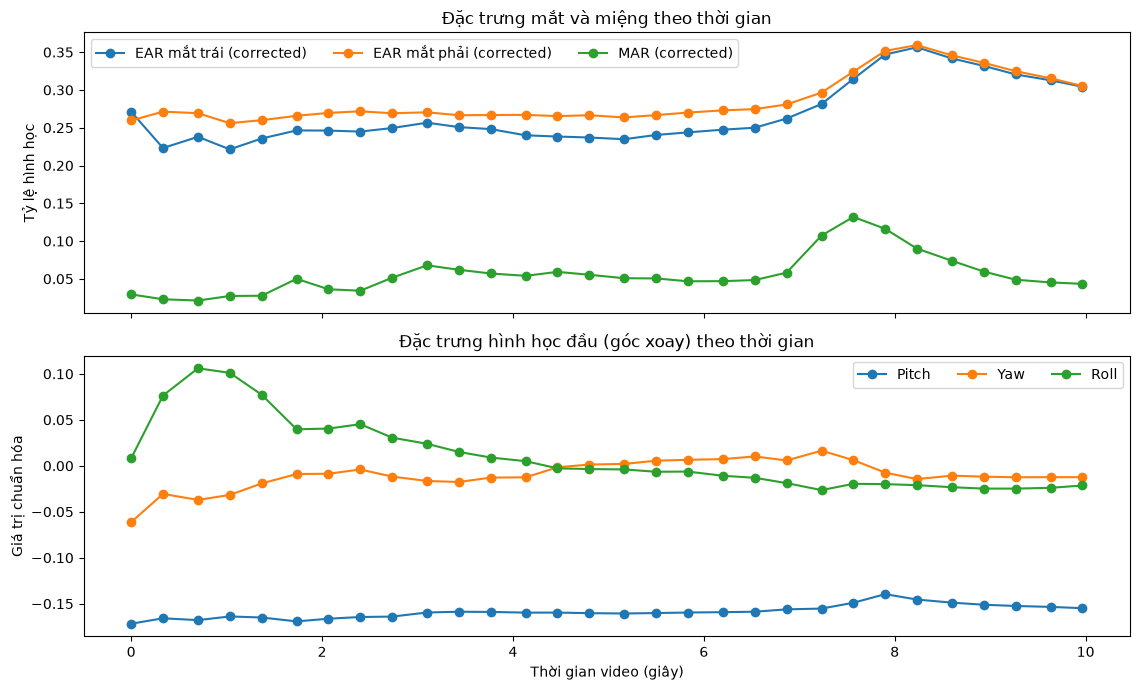

In [5]:
sample_indices = np.linspace(0, max(0, frame_count - 1), 30).round().astype(int)
sequence_30 = []
cap = cv2.VideoCapture(str(VIDEO_PATH))
for frame_idx in sample_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, bgr = cap.read()
    if not ok:
        sequence_30.append(np.zeros(168, dtype=np.float32))
        continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    detected = detector.process(rgb)
    if detected.multi_face_landmarks:
        feat = _build_frame_feature(
            detected.multi_face_landmarks[0],
            feature_set='depth_robust_v2',
            image_aspect_ratio=width/height,
            face_blendshapes=getattr(detected, 'face_blendshapes', None),
            facial_transformation_matrixes=getattr(detected, 'facial_transformation_matrixes', None)
        )
        sequence_30.append(feat)
    else:
        sequence_30.append(np.zeros(168, dtype=np.float32))
cap.release()

sequence_30 = np.stack(sequence_30).astype(np.float32)
time_seconds = sample_indices / max(fps, 1e-6)

fig, axes = plt.subplots(2, 1, figsize=(11.5, 7), sharex=True)
axes[0].plot(time_seconds, sequence_30[:, 0], marker='o', label='EAR mắt trái (corrected)')
axes[0].plot(time_seconds, sequence_30[:, 1], marker='o', label='EAR mắt phải (corrected)')
axes[0].plot(time_seconds, sequence_30[:, 2], marker='o', label='MAR (corrected)')
axes[0].set(ylabel='Tỷ lệ hình học', title='Đặc trưng mắt và miệng theo thời gian')
axes[0].legend(ncol=3)

axes[1].plot(time_seconds, sequence_30[:, 3], marker='o', label='Pitch')
axes[1].plot(time_seconds, sequence_30[:, 4], marker='o', label='Yaw')
axes[1].plot(time_seconds, sequence_30[:, 5], marker='o', label='Roll')
axes[1].set(xlabel='Thời gian video (giây)', ylabel='Giá trị chuẩn hóa', title='Đặc trưng hình học đầu (góc xoay) theo thời gian')
axes[1].legend(ncol=3)

fig.tight_layout()
fig.savefig(OUT_DIR / '04_dac_trung_video_theo_thoi_gian.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '04_dac_trung_video_theo_thoi_gian.png', bbox_inches='tight', facecolor='white')
plt.show()


## 5. Làm giàu đặc trưng: 168 chiều lên 504 chiều (30 × 504)
Thực hiện làm giàu đặc trưng qua thời gian bằng cách tính toán hiệu phân sai (vận tốc) và độ lệch chuẩn của cửa sổ, tạo thành tensor 30 × 504.


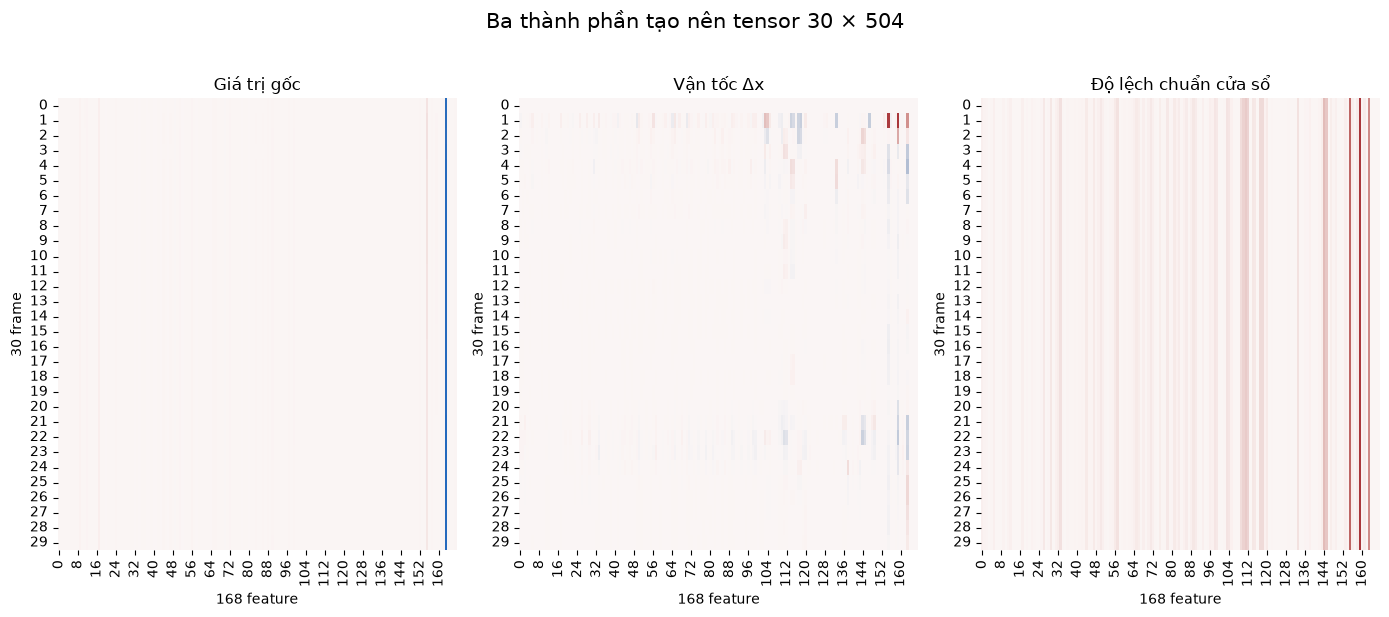

In [6]:
frame_features_list = [row for row in sequence_30]
frame_features_interpolated = _interpolate_missing_v2(frame_features_list)
enriched_504 = _window_frames(frame_features_interpolated, feature_set='depth_robust_v2', temporal_enrichment='velocity_std')[0]

raw_part = enriched_504[:, :168]
velocity_part = enriched_504[:, 168:336]
std_part = enriched_504[:, 336:504]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6))
sns.heatmap(raw_part, cmap='vlag', center=0, cbar=False, ax=ax1)
ax1.set(title='Giá trị gốc', xlabel='168 feature', ylabel='30 frame')

sns.heatmap(velocity_part, cmap='vlag', center=0, cbar=False, ax=ax2)
ax2.set(title='Vận tốc Δx', xlabel='168 feature', ylabel='30 frame')

sns.heatmap(std_part, cmap='vlag', center=0, cbar=False, ax=ax3)
ax3.set(title='Độ lệch chuẩn cửa sổ', xlabel='168 feature', ylabel='30 frame')

fig.suptitle('Ba thành phần tạo nên tensor 30 × 504', y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(OUT_DIR / '05_lam_giau_168_len_504.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '05_lam_giau_168_len_504.png', bbox_inches='tight', facecolor='white')
plt.show()

detector.close()
